# Model Predictions

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import torch, yaml
from src.models import ResNet, ResidualBlock
import random
from torch.utils.data import DataLoader
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from src.inference import inference_resnet_model
from src.evaluation import calculate_metrics
from src.utils import set_all_seeds

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

In [ ]:
# Paper-quality defaults
mpl.rcParams.update({
    "figure.dpi":        300,
    "font.family":       "serif",
    "font.size":         9,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "savefig.bbox":      "tight",
})

In [ ]:
# Set random seeds for reproducibility
SEED = 42
set_all_seeds(SEED)

# Set device 
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
print("Using device:", device)

Using device: mps


In [55]:
# Experiment directory
exp_dir = Path('../res/2025-05-21_20-36-15_engine_2_6638a4af')

indices_dir = exp_dir / "indices"
checkpoints_dir = exp_dir / "checkpoints"
fig_dir = exp_dir / "figs"

base_dir = Path('../dataset/engine_2')

## Load Data

In [56]:
# Load segments and metadata
segments  = np.load(base_dir / "segments.npy", mmap_mode="r")
freqs     = np.load(base_dir / "freqs.npy", mmap_mode="r")

seg_meta_df = pd.read_csv(base_dir / "segments_metadata.csv", index_col=["measurement_id", "segment_idx"])
seg_meta_df

base_id   start_time     end_time  \
measurement_id segment_idx                                         
1727864902_1   0            1727864902     0.000000  2441.162109   
               1            1727864902     4.882812  2446.044922   
               2            1727864902     9.765625  2450.927734   
               3            1727864902    14.648438  2455.810547   
               4            1727864902    19.531250  2460.693359   
...                                ...          ...          ...   
1727784371_2   315          1727784371  1538.085938  3979.248047   
               316          1727784371  1542.968750  3984.130859   
               317          1727784371  1547.851562  3989.013672   
               318          1727784371  1552.734375  3993.896484   
               319          1727784371  1557.617188  3998.779297   

                                       state  binary_label  multiclass_label  \
measurement_id segment_idx                                                     
1727864902_1   0              bearing defect             1    bearing defect   
               1              bearing defect             1    bearing defect   
               2              bearing defect             1    bearing defect   
               3              bearing defect             1    bearing defect   
               4              bearing defect             1    bearing defect   
...                                      ...           ...               ...   
1727784371_2   315          rotor bar defect             1  rotor bar defect   
               316          rotor bar defect             1  rotor bar defect   
               317          rotor bar defect             1  rotor bar defect   
               318          rotor bar defect             1  rotor bar defect   
               319          rotor bar defect             1  rotor bar defect   

                            phase  load_condition    experiment  
measurement_id segment_idx                                       
1727864902_1   0                1              80  experiment_1  
               1                1              80  experiment_1  
               2                1              80  experiment_1  
               3                1              80  experiment_1  
               4                1              80  experiment_1  
...                           ...             ...           ...  
1727784371_2   315              2              40  experiment_1  
               316              2              40  experiment_1  
               317              2              40  experiment_1  
               318              2              40  experiment_1  
               319              2              40  experiment_1  

[460800 rows x 9 columns]

In [ ]:
# Filter segments

import yaml
with open("../res/inference.yml", "r") as f:
    train_params = yaml.safe_load(f)

fault_types_to_use = train_params["processing_parameters"]["fault_types_to_use"]
training_classes = fault_types_to_use + ['normal']
loads_to_use = train_params["processing_parameters"]["loads_to_use"]
phases_to_use = train_params["processing_parameters"]["phases_to_use"]

# Filter states using fault_types_to_use with 'normal'
training_classes_mask = seg_meta_df['state'].isin(training_classes)

# Filter loads using loads_to_use
loads_mask = seg_meta_df['load_condition'].isin(loads_to_use)

# Filter phases using phases_to_use
phases_mask = seg_meta_df['phase'].isin(phases_to_use)

# Final mask
mask = training_classes_mask & loads_mask & phases_mask

In [58]:
# Apply mask
segments = segments[mask]
seg_meta_df = seg_meta_df[mask]

In [ ]:
from src.evaluation import slice_metrics
from src.visualization import plot_heatmap

## Binary Classification

In [63]:
# Load Normalizer
from src.normalization import Normalizer
normalizer = Normalizer(method='min-max', mode='global').load(path=exp_dir / 'normalizer.json')

# Load trained model
ckpt_path_binary = checkpoints_dir / 'resnet_best_binary.pth'
ckpt = torch.load(ckpt_path_binary, map_location=device, weights_only=False)

# Load mask
mask_path_binary = exp_dir / 'mask.pt'
mask_binary = torch.load(mask_path_binary, map_location=device)

### Load Model

In [64]:
# Load Model
model_bin = ResNet(
    ResidualBlock, [2,2,2,2],
    num_classes = 2,
    dropout_rate= 0.2,
    # BandWeightAttention
    prior_kwargs = dict(
        mask          = mask_binary,
        w_in_init     = 1.2,    # neutral start inside bands
        w_out_init    = 0.0,    # hard zero outside
        learnable_in  = True,   # let the model boost inside if it wants
        learnable_out = False,  # keep outside at 0
    )
).to(device)
model_bin.load_state_dict(ckpt['state'])
model_bin.eval()

ResNet(
  (conv): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (prior_attn): BandWeightAttention()
  (layer1): Sequential(
    (0): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (1): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
  )
  (layer2): Sequential(
    (0): Resi

### Data for Inference

In [66]:
# Load train/val/test indices from training
train_idx = np.load(indices_dir / "train_idx_binary.npy", allow_pickle=True)
val_idx   = np.load(indices_dir / "val_idx_binary.npy", allow_pickle=True)
test_idx  = np.load(indices_dir / "test_idx_binary.npy", allow_pickle=True)

# This is a split of the filtered dataset. To get full picture we need to test algorithm on whole dataset
# To accomplish it we create a new test set with all segments from the dataset except the ones used in training
# and validation.

train_val_idx = np.concatenate([train_idx, val_idx])
train_val_idx = pd.Index(train_val_idx, copy=False)
full_index = seg_meta_df.index
full_test_idx = full_index.difference(train_val_idx)

# Map full_test_idx (MultiIndex) to integer row numbers
full_test_idx_nums = [full_index.get_loc(ind) for ind in full_test_idx]
full_test_idx_nums = pd.Index(full_test_idx_nums, copy=False)

In [67]:
# 1 · vectorised conversion: MultiIndex → row positions
full_test_pos = seg_meta_df.index.get_indexer(full_test_idx)

# 2 · slice & normalise
X_test = segments[full_test_pos]        

if normalizer is not None:
    X_test = normalizer.transform(X_test)

y_test = seg_meta_df.loc[full_test_idx, "binary_label"].values.astype(np.int64)

In [69]:
from torch.utils.data import TensorDataset

# 3 · TensorDataset & DataLoader
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test).unsqueeze(1),   # (N,1,L)
                  torch.tensor(y_test)),
    batch_size=1024, shuffle=False
)

# 4 · Inference
true_bin, pred_bin = inference_resnet_model(model_bin, test_loader, device=device)

Inference:   0%|          | 0/212 [00:00<?, ?batch/s]

In [70]:
predictions_df = (
    seg_meta_df.loc[full_test_idx].copy()
    .assign(
        binary_prediction       = pred_bin,                       
        binary_prediction_state = np.where(pred_bin == 0,
                                           "normal", "anomalous")
    )
)

In [71]:
predictions_df

base_id   start_time     end_time  \
measurement_id segment_idx                                         
1727783110_1   0            1727783110     0.000000  2441.162109   
               1            1727783110     4.882812  2446.044922   
               2            1727783110     9.765625  2450.927734   
               3            1727783110    14.648438  2455.810547   
               4            1727783110    19.531250  2460.693359   
...                                ...          ...          ...   
1727937757_3   315          1727937757  1538.085938  3979.248047   
               316          1727937757  1542.968750  3984.130859   
               317          1727937757  1547.851562  3989.013672   
               318          1727937757  1552.734375  3993.896484   
               319          1727937757  1557.617188  3998.779297   

                                                state  binary_label  \
measurement_id segment_idx                                            
1727783110_1   0                     rotor bar defect             1   
               1                     rotor bar defect             1   
               2                     rotor bar defect             1   
               3                     rotor bar defect             1   
               4                     rotor bar defect             1   
...                                               ...           ...   
1727937757_3   315          inter-turn short circuits             1   
               316          inter-turn short circuits             1   
               317          inter-turn short circuits             1   
               318          inter-turn short circuits             1   
               319          inter-turn short circuits             1   

                                     multiclass_label  phase  load_condition  \
measurement_id segment_idx                                                     
1727783110_1   0                     rotor bar defect      1               0   
               1                     rotor bar defect      1               0   
               2                     rotor bar defect      1               0   
               3                     rotor bar defect      1               0   
               4                     rotor bar defect      1               0   
...                                               ...    ...             ...   
1727937757_3   315          inter-turn short circuits      3             100   
               316          inter-turn short circuits      3             100   
               317          inter-turn short circuits      3             100   
               318          inter-turn short circuits      3             100   
               319          inter-turn short circuits      3             100   

                              experiment  binary_prediction  \
measurement_id segment_idx                                    
1727783110_1   0            experiment_1                  1   
               1            experiment_1                  0   
               2            experiment_1                  1   
               3            experiment_1                  1   
               4            experiment_1                  1   
...                                  ...                ...   
1727937757_3   315          experiment_1                  1   
               316          experiment_1                  1   
               317          experiment_1                  1   
               318          experiment_1                  1   
               319          experiment_1                  1   

                           binary_prediction_state  
measurement_id segment_idx                          
1727783110_1   0                         anomalous  
               1                            normal  
               2                         anomalous  
               3                         anomalous  
               4                         an

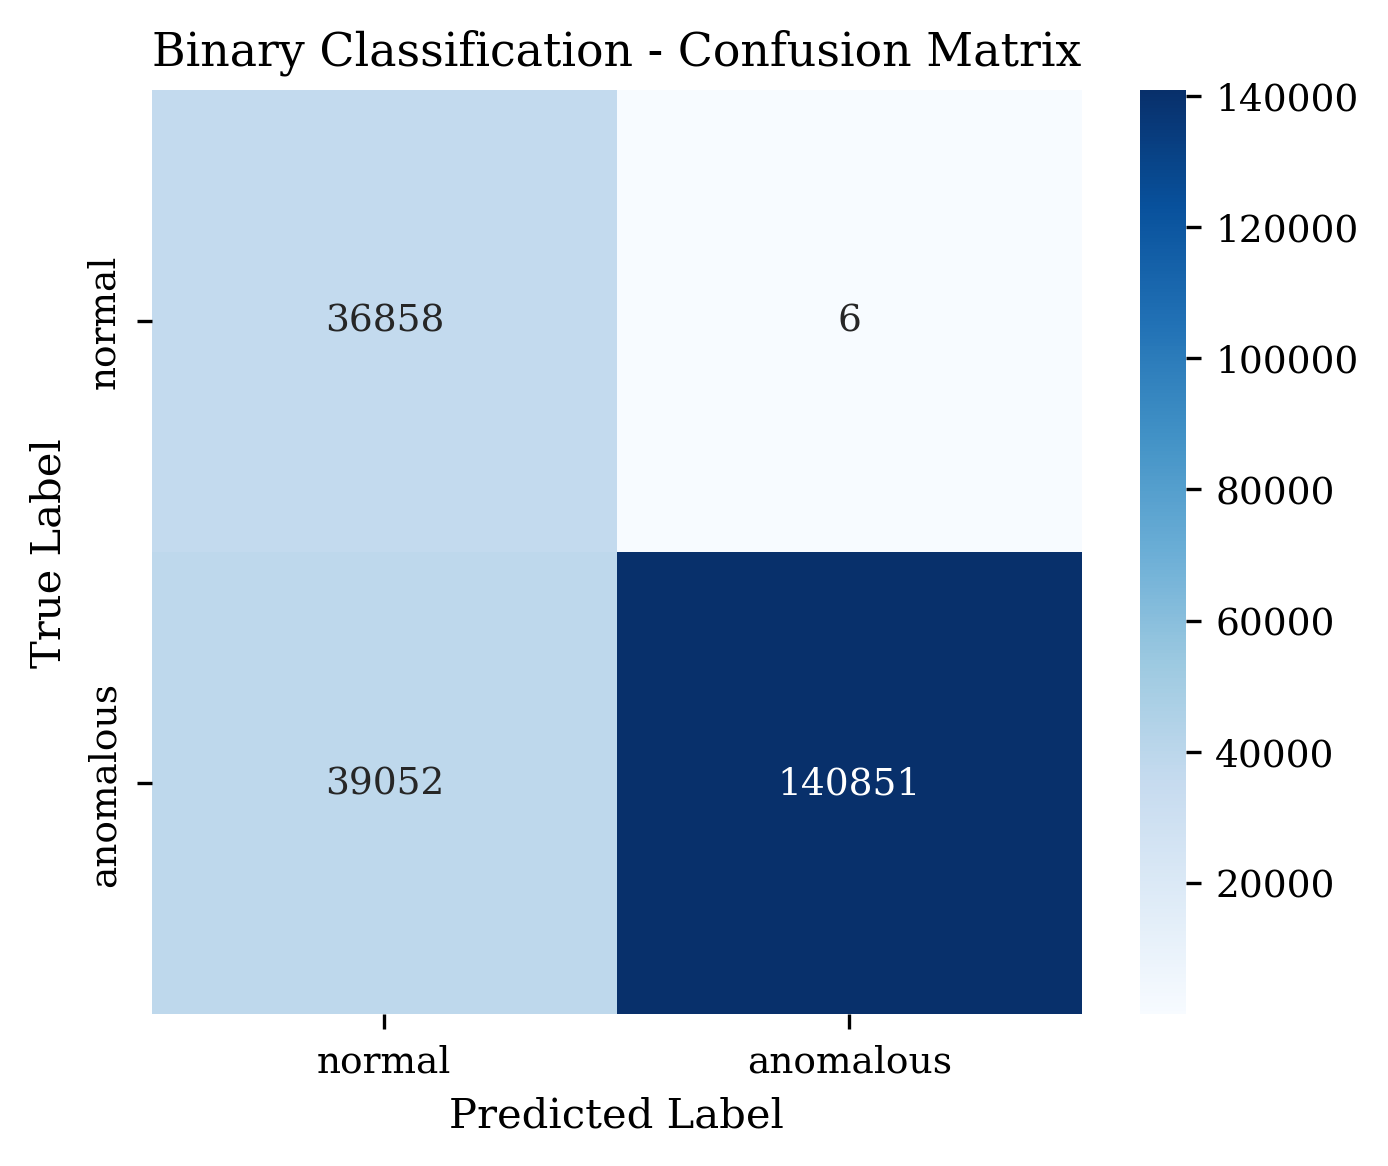

              precision    recall  f1-score   support

      normal       0.49      1.00      0.65     36864
   anomalous       1.00      0.78      0.88    179903

    accuracy                           0.82    216767
   macro avg       0.74      0.89      0.77    216767
weighted avg       0.91      0.82      0.84    216767



In [74]:
import seaborn as sns
from sklearn.metrics import classification_report

# 5 · Metrics & confusion matrix
cm_bin, acc_bin, prec_bin, rec_bin, f1_bin = calculate_metrics(true_bin, pred_bin)

fig_bin, ax_bin = plt.subplots(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal','anomalous'], yticklabels=['normal','anomalous'], ax=ax_bin)
ax_bin.set_xlabel('Predicted Label')
ax_bin.set_ylabel('True Label')
ax_bin.set_title('Binary Classification - Confusion Matrix')
plt.show()

print(classification_report(true_bin, pred_bin,
                            target_names=['normal','anomalous']))


In [ ]:
# ── Binary results  ─────────────────────────────────────────────────

bin_metrics = slice_metrics(
    predictions_df,
    y_true="binary_label",
    y_pred="binary_prediction",
    average="binary",
)

# pivot → heat-map friendly table
f1_bin = bin_metrics.pivot(index="load", columns="phase", values="f1")

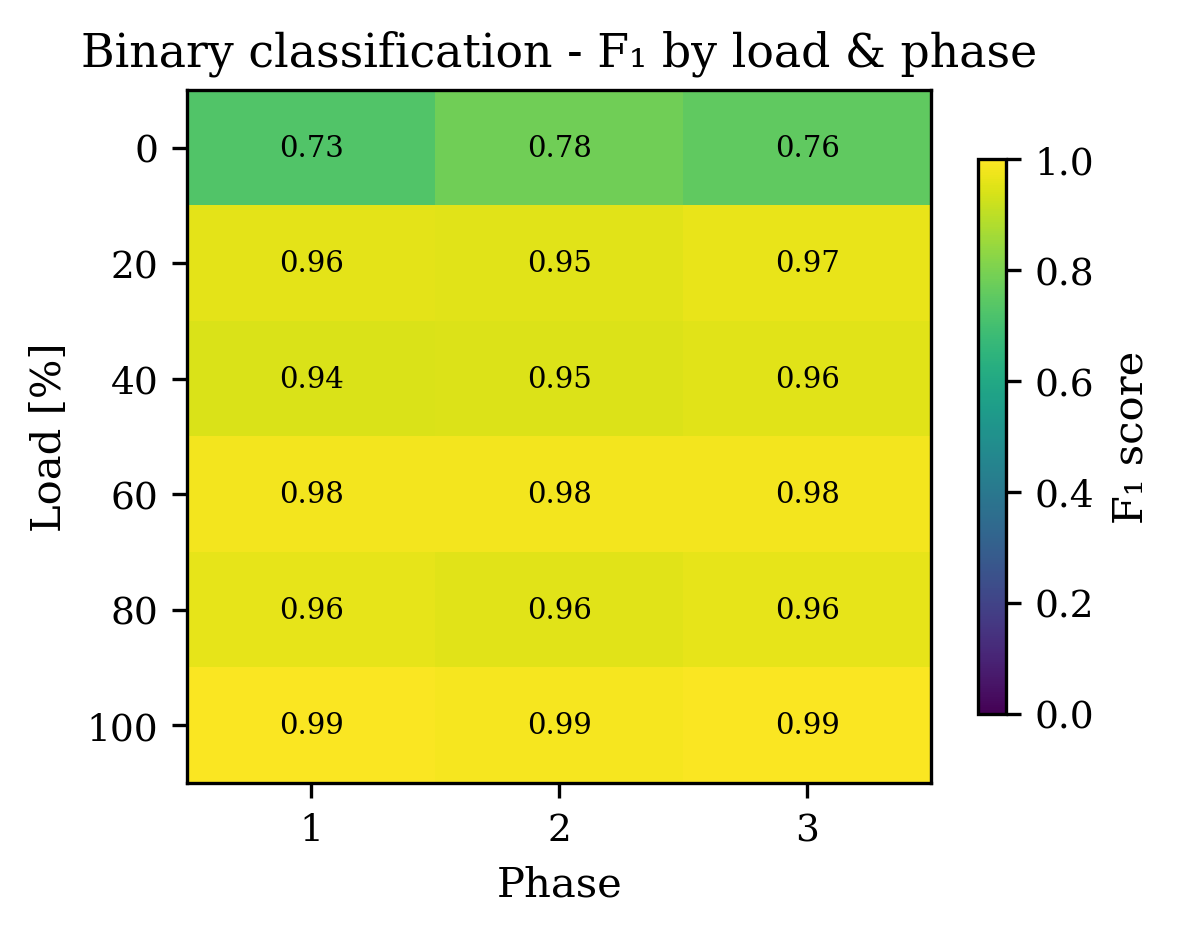

In [18]:
plot_heatmap(f1_bin,   "Binary classification - F₁ by load & phase", save=True)

In [ ]:
# ──────────────────────────────────────────────────────────────────────────
# Binary – Measurement-level aggregation
# ──────────────────────────────────────────────────────────────────────────
agg_bin = (
    predictions_df
    .groupby(level=0)                      # each measurement_id
    .agg(
        n_segments         = ('binary_prediction', 'size'),
        n_pred_anomalous   = ('binary_prediction', 'sum'),
        true_binary_label  = ('binary_label', 'first')   # identical for all segments
    )
)
agg_bin["frac_anomalous"]       = agg_bin["n_pred_anomalous"] / agg_bin["n_segments"]
agg_bin["pred_binary_majority"] = (agg_bin["frac_anomalous"] >= 0.5).astype(int)

# ── Metrics (measurement granularity)
acc_bin = accuracy_score(agg_bin["true_binary_label"], agg_bin["pred_binary_majority"])
prc_bin, rec_bin, f1_bin, _ = precision_recall_fscore_support(
    agg_bin["true_binary_label"],
    agg_bin["pred_binary_majority"],
    average="binary",
    zero_division=0,
)

print(f"Binary @ measurement level →  Accuracy={acc_bin:.3f}, "
      f"Precision={prc_bin:.3f}, Recall={rec_bin:.3f}, F1={f1_bin:.3f}")


agg_bin.to_csv(os.path.join(base_dir, "measurement_metrics_binary.csv"))

Binary @ measurement level →  Accuracy=0.976, Precision=0.967, Recall=0.995, F1=0.981


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
#  Majority-vote heat-maps  (measurement granularity)                    ║
#  ––– needs the existing objects:                                       ║
#        • agg_bin              (binary majority vote)                   ║
#        • label_counts         (multiclass majority vote)               ║
#        • predictions_df       – any segment row for meta lookup        ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ──────────────────────────────────────────────────────────────────────────
# A.  Add phase & load_condition to the majority-vote tables
# ──────────────────────────────────────────────────────────────────────────
# (they’re constant per measurement → take `.first()`)

meta_cols = predictions_df.groupby(level=0)[["phase", "load_condition"]].first()
agg_bin   = agg_bin.join(meta_cols)              # binary table

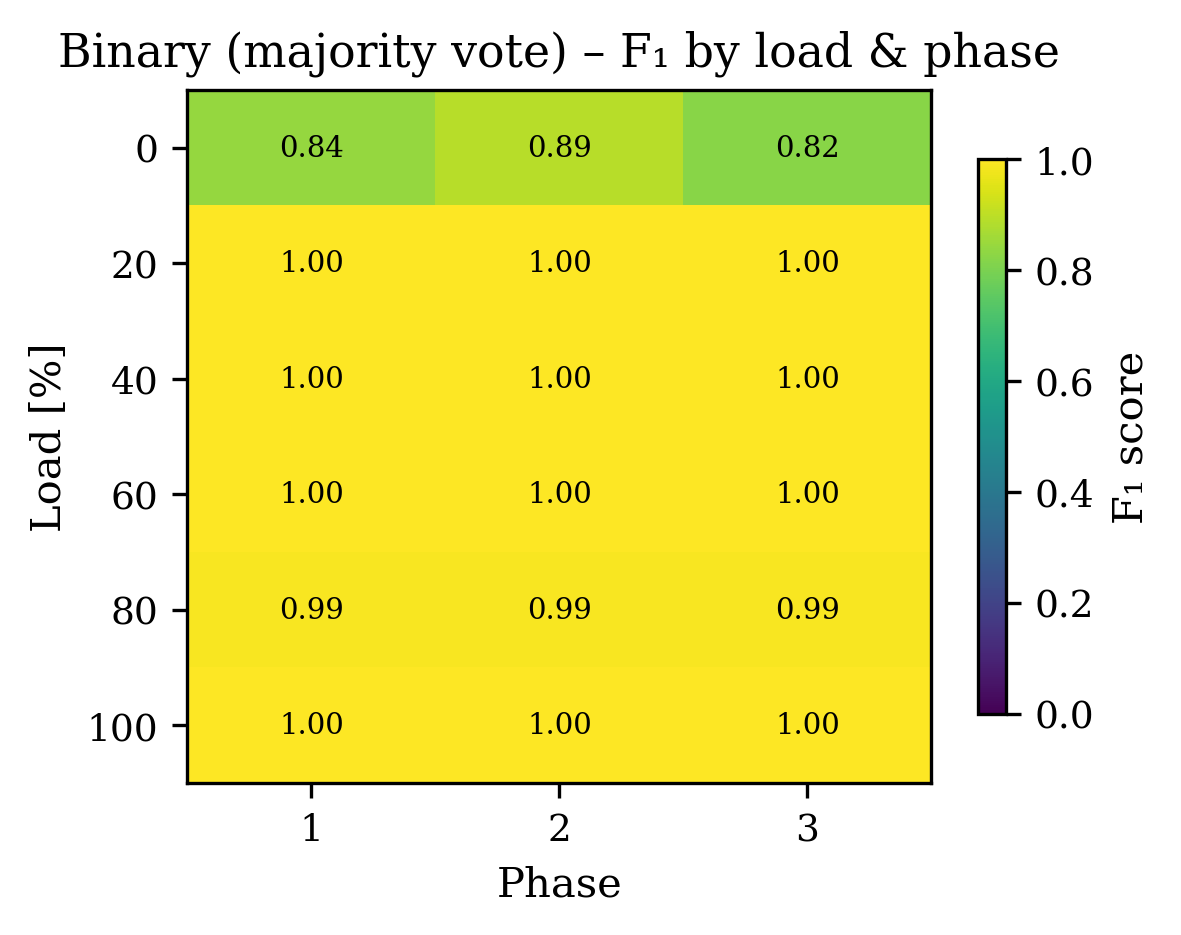

In [21]:
# ── Binary – after majority vote  ───────────────────────────────────────
bin_mv_metrics = slice_metrics(
    agg_bin,
    y_true="true_binary_label",
    y_pred="pred_binary_majority",
    average="binary",
)
f1_bin_mv = bin_mv_metrics.pivot(index="load", columns="phase", values="f1")
n_bin_mv  = bin_mv_metrics.pivot(index="load", columns="phase", values="n")

plot_heatmap(
    f1_bin_mv,
    "Binary (majority vote) – F₁ by load & phase",
    save=True
    # counts_mat=n_bin_mv
)

## Multiclass Classification

In [32]:
# Load Normalizer
from src.normalization import Normalizer
normalizer = Normalizer(method='min-max', mode='global').load(path=base_dir / 'normalizer.json')

# Load trained model
ckpt_path_multiclass = ckpt_path / 'resnet_best_multiclass.pth'
ckpt_multi = torch.load(ckpt_path_multiclass, map_location=device, weights_only=False)

# Load mask
mask_path_multi = base_dir / 'mask.pt'
mask_multi = torch.load(mask_path_multi, map_location=device)

# Load Model
model_multi = ResNet(
    ResidualBlock, [2,2,2,2],
    num_classes = 3,
    dropout_rate= 0.2,
    # BandWeightAttention
    prior_kwargs = dict(
        mask          = mask_multi,
        w_in_init     = 1.2,    # neutral start inside bands
        w_out_init    = 0.0,    # hard zero outside
        learnable_in  = True,   # let the model boost inside if it wants
        learnable_out = False,  # keep outside at 0
    )
).to(device)
model_multi.load_state_dict(ckpt_multi['state'])
model_multi.eval()

# Load label encoder
import joblib
label_encoder = joblib.load(Path("../res/label_encoders/label_encoder_multiclass.pkl"))
n_classes = len(label_encoder.classes_)

In [ ]:
# 3 · build test-loader (reuse full_test_pos from binary cell)
X_test_m = segments[full_test_pos]
if normalizer is not None:
    X_test_m = normalizer.transform(X_test_m)

y_test_m = seg_meta_df.loc[full_test_idx, "multiclass_label"].values
y_test_m_int = label_encoder.transform(y_test_m).astype(np.int64)

test_loader_m = DataLoader(
    TensorDataset(torch.tensor(X_test_m).unsqueeze(1),
                  torch.tensor(y_test_m_int)),
    batch_size=1024, shuffle=False
)

In [34]:
# 4 · inference
true_m, pred_m = inference_resnet_model(model_multi, test_loader_m, device=device)

Inference:   0%|          | 0/314 [00:00<?, ?batch/s]

In [35]:
# 5 · Add to the DataFrame
predictions_df["multiclass_prediction"] = pred_m.astype(np.int64)
predictions_df["multiclass_prediction_state"] = label_encoder.inverse_transform(pred_m)

In [36]:
predictions_df

base_id   start_time     end_time  \
measurement_id segment_idx                                         
1727783110_1   0            1727783110     0.000000  2441.162109   
               1            1727783110     4.882812  2446.044922   
               2            1727783110     9.765625  2450.927734   
               3            1727783110    14.648438  2455.810547   
               4            1727783110    19.531250  2460.693359   
...                                ...          ...          ...   
1727937757_3   315          1727937757  1538.085938  3979.248047   
               316          1727937757  1542.968750  3984.130859   
               317          1727937757  1547.851562  3989.013672   
               318          1727937757  1552.734375  3993.896484   
               319          1727937757  1557.617188  3998.779297   

                                                state  binary_label  \
measurement_id segment_idx                                            
1727783110_1   0                     rotor bar defect             1   
               1                     rotor bar defect             1   
               2                     rotor bar defect             1   
               3                     rotor bar defect             1   
               4                     rotor bar defect             1   
...                                               ...           ...   
1727937757_3   315          inter-turn short circuits             1   
               316          inter-turn short circuits             1   
               317          inter-turn short circuits             1   
               318          inter-turn short circuits             1   
               319          inter-turn short circuits             1   

                                     multiclass_label  phase  load_condition  \
measurement_id segment_idx                                                     
1727783110_1   0                     rotor bar defect      1               0   
               1                     rotor bar defect      1               0   
               2                     rotor bar defect      1               0   
               3                     rotor bar defect      1               0   
               4                     rotor bar defect      1               0   
...                                               ...    ...             ...   
1727937757_3   315          inter-turn short circuits      3             100   
               316          inter-turn short circuits      3             100   
               317          inter-turn short circuits      3             100   
               318          inter-turn short circuits      3             100   
               319          inter-turn short circuits      3             100   

                              experiment  binary_prediction  \
measurement_id segment_idx                                    
1727783110_1   0            experiment_1                  1   
               1            experiment_1                  1   
               2            experiment_1                  1   
               3            experiment_1                  1   
               4            experiment_1                  1   
...                                  ...                ...   
1727937757_3   315          experiment_1                  1   
               316          experiment_1                  1   
               317          experiment_1                  1   
               318          experiment_1                  1   
               319          experiment_1                  1   

                           binary_prediction_state  multiclass_prediction  \
measurement_id segment_idx                                                  
1727783110_1   0                         anomalous                      0   
               1                         anomalous                      1   
               2                         anomalous   

In [ ]:
# ── Multiclass results  (macro-averaged)  ───────────────────────────
multi_metrics = slice_metrics(
    predictions_df,
    y_true="multiclass_label",
    y_pred="multiclass_prediction_state",
    average="macro",
)
f1_multi = multi_metrics.pivot(index="load", columns="phase", values="f1")

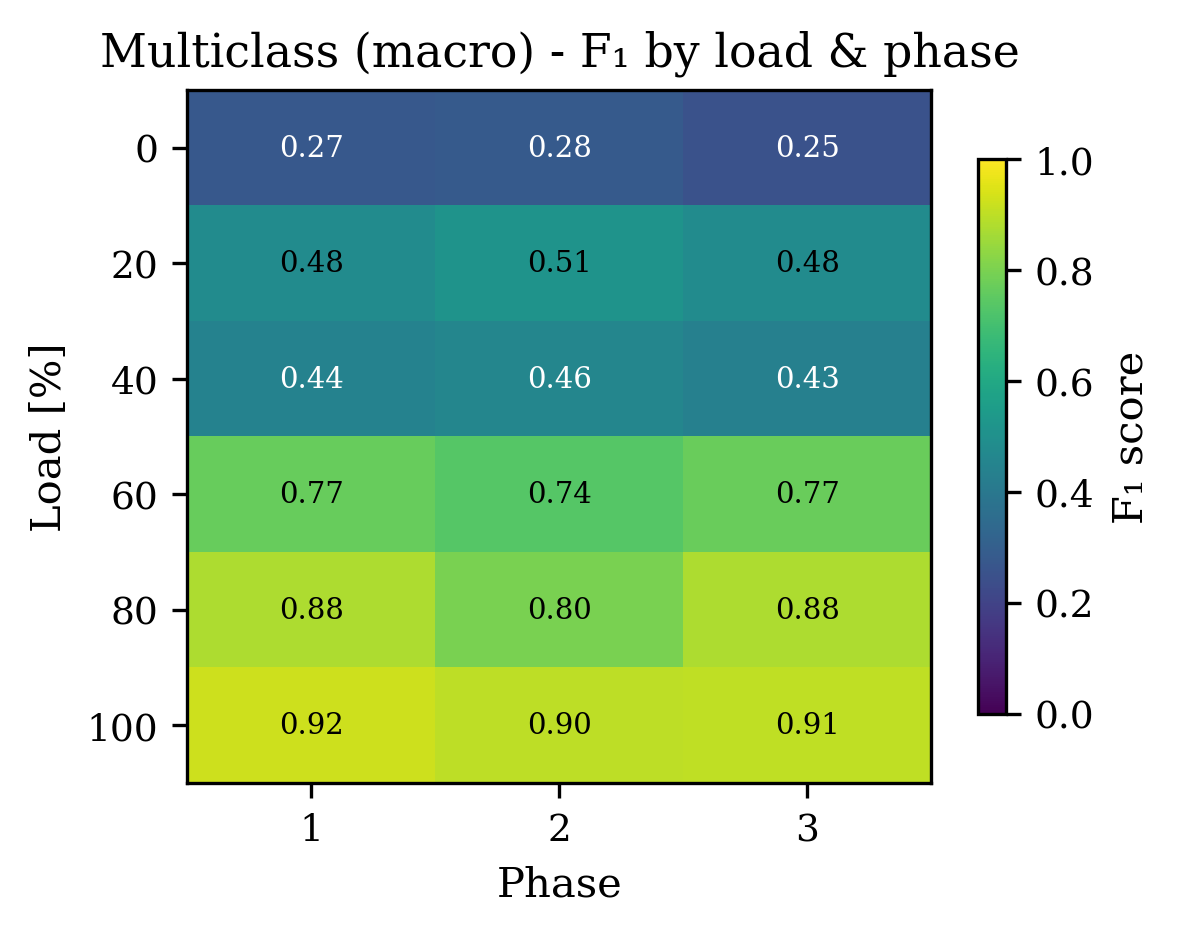

In [47]:
plot_heatmap(f1_multi, 
             "Multiclass (macro) - F₁ by load & phase",
             save=True)

In [ ]:
# ──────────────────────────────────────────────────────────────────────────
# Multiclass – Measurement-level aggregation
# ──────────────────────────────────────────────────────────────────────────
# Count the relative frequency of every predicted label per measurement
label_counts = (
    predictions_df
    .groupby(level=0)["multiclass_prediction_state"]
    .value_counts(normalize=True)          # relative freq’s ∈ [0,1]
    .unstack(fill_value=0)
)

# Append ground-truth and majority-vote prediction
label_counts["true_label"] = (
    predictions_df.groupby(level=0)["multiclass_label"].first()
)
label_counts["pred_majority_label"] = (
    label_counts.drop(columns="true_label").idxmax(axis=1)
)

# ── Metrics (macro-averaged over measurements)
y_true_m   = label_counts["true_label"]
y_pred_m   = label_counts["pred_majority_label"]

acc_multi = accuracy_score(y_true_m, y_pred_m)
prc_multi, rec_multi, f1_multi, _ = precision_recall_fscore_support(
    y_true_m, y_pred_m,
    average="macro",
    zero_division=0,
)

print(f"Multiclass @ measurement level →  Accuracy={acc_multi:.3f}, "
      f"Precision={prc_multi:.3f}, Recall={rec_multi:.3f}, F1={f1_multi:.3f}")

# Save
label_counts.to_csv(os.path.join(base_dir, "measurement_metrics_multiclass.csv"))

Multiclass @ measurement level →  Accuracy=0.829, Precision=0.841, Recall=0.852, F1=0.819


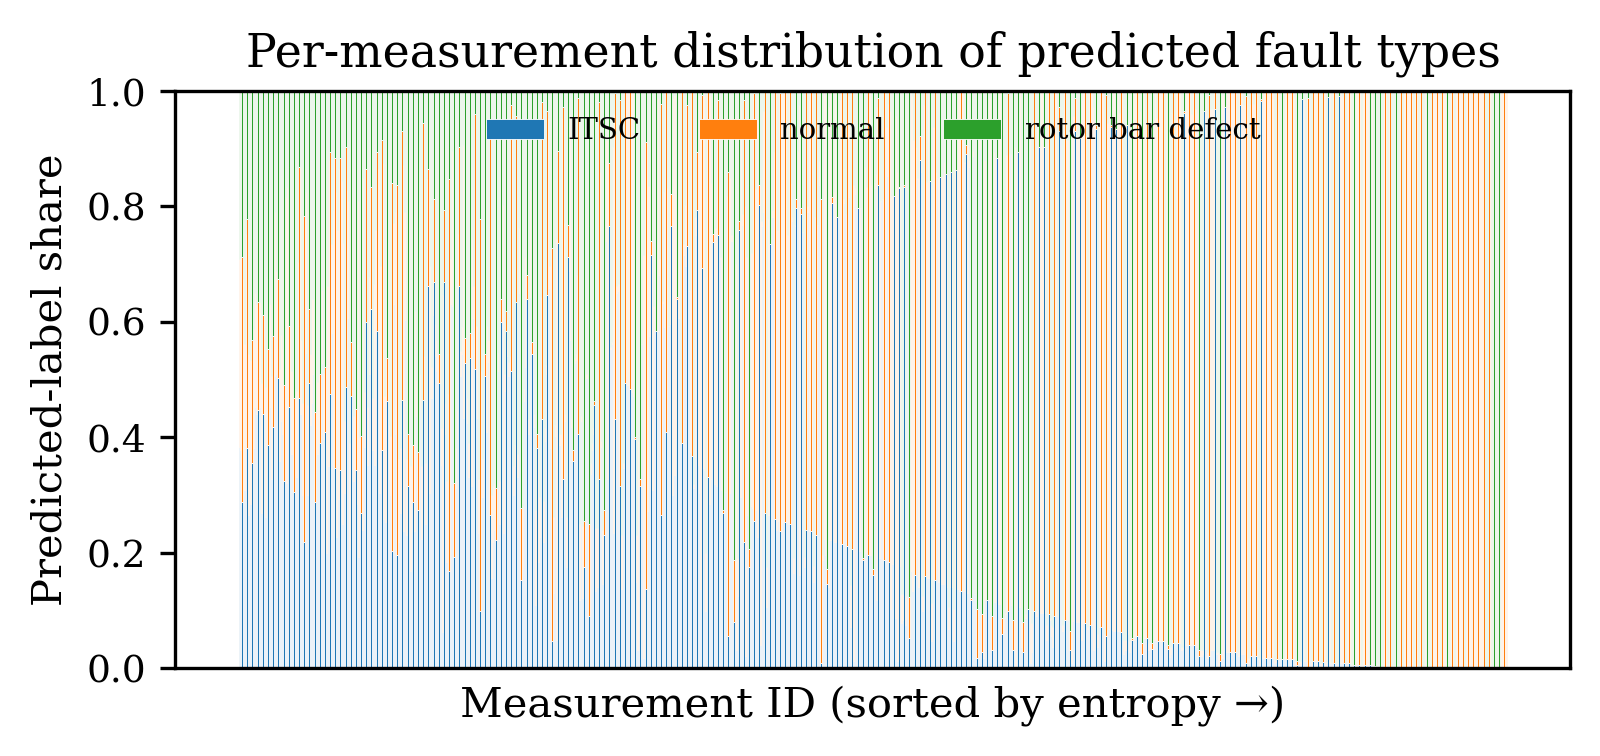

In [ ]:
#   Multiclass stacked bar chart
#   Sort measurements by Shannon entropy of the predicted distribution
entropy = - (label_counts.drop(columns=["true_label", "pred_majority_label"]) * 
             np.log2(label_counts.drop(columns=["true_label", "pred_majority_label"]) + 1e-12)
            ).sum(axis=1)
label_counts_sorted = label_counts.assign(entropy=entropy).sort_values("entropy", ascending=False)

classes = [c for c in label_counts.columns if c not in ["true_label", "pred_majority_label"]]
fig, ax = plt.subplots(figsize=(6, 2.5))

bottom = np.zeros(len(label_counts_sorted))
for cls in classes:
    vals = label_counts_sorted[cls].values
    ax.bar(
        np.arange(len(vals)),
        vals,
        bottom=bottom,
        label=cls.replace('inter-turn short circuits', 'ITSC'),
        width=1.0,
        edgecolor='white',
        linewidth=0.2,
    )
    bottom += vals

ax.set_xlabel("Measurement ID (sorted by entropy →)")
ax.set_ylabel("Predicted-label share")
ax.set_title("Per-measurement distribution of predicted fault types")
ax.set_ylim(0, 1)
ax.set_xticks([])
# ax.legend()
ax.legend(
    frameon=False, ncol=len(classes), fontsize=7, loc="upper center"
)
plt.show()

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
#  Majority-vote heat-maps  (measurement granularity)                    ║
#  ––– needs the existing objects:                                       ║
#        • agg_bin              (binary majority vote)                   ║
#        • label_counts         (multiclass majority vote)               ║
#        • predictions_df       – any segment row for meta lookup        ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ──────────────────────────────────────────────────────────────────────────
# A.  Add phase & load_condition to the majority-vote tables
# ──────────────────────────────────────────────────────────────────────────
# (they’re constant per measurement → take `.first()`)

meta_cols = predictions_df.groupby(level=0)[["phase", "load_condition"]].first()
label_counts = label_counts.join(meta_cols)

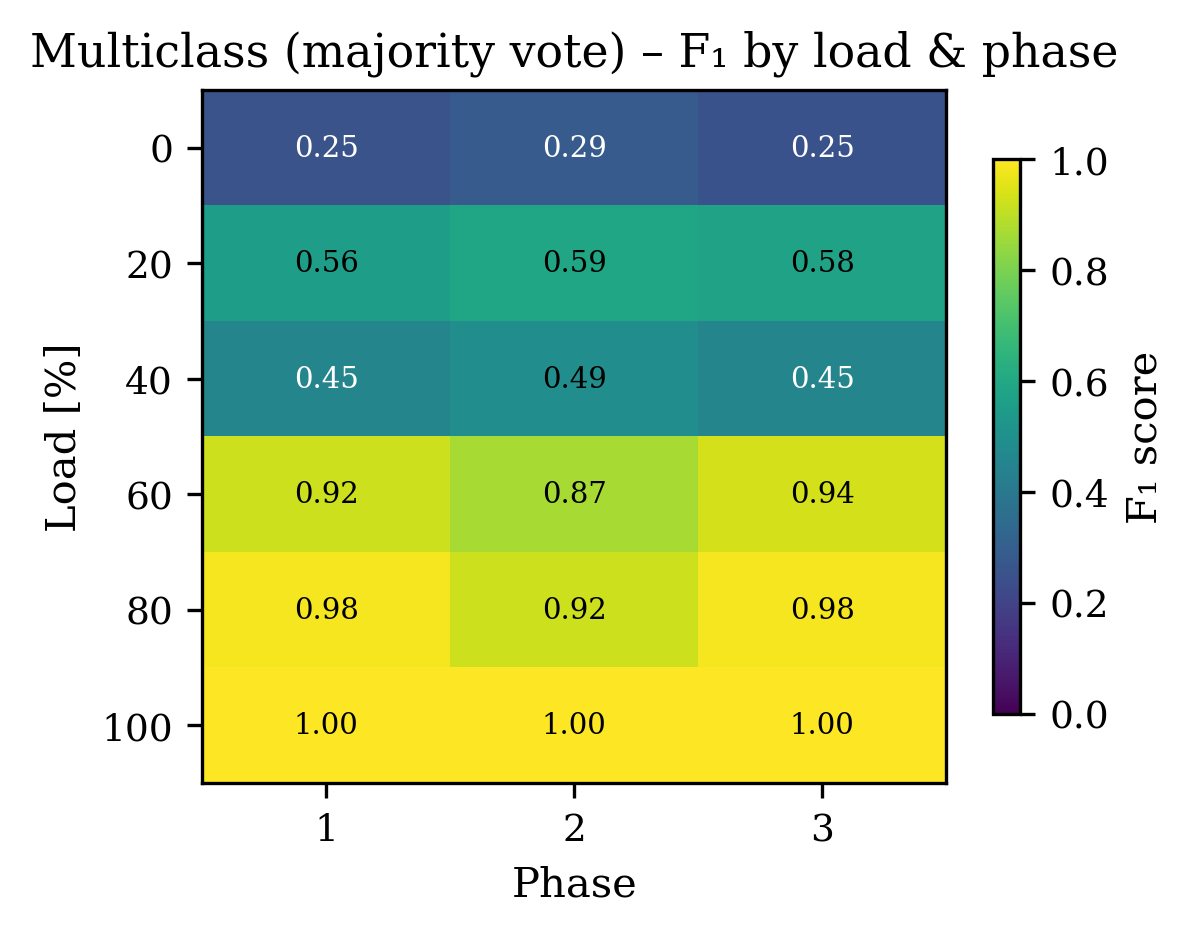

In [43]:
# ── Multiclass – after majority vote  ────────────────────────────────────
multi_mv_metrics = slice_metrics(
    label_counts,
    y_true="true_label",
    y_pred="pred_majority_label",
    average="macro",
)
f1_multi_mv = multi_mv_metrics.pivot(index="load", columns="phase", values="f1")
n_multi_mv  = multi_mv_metrics.pivot(index="load", columns="phase", values="n")

plot_heatmap(
    f1_multi_mv,
    "Multiclass (majority vote) – F₁ by load & phase",
    save=True
)

## Multiclass Prediction -> Binary

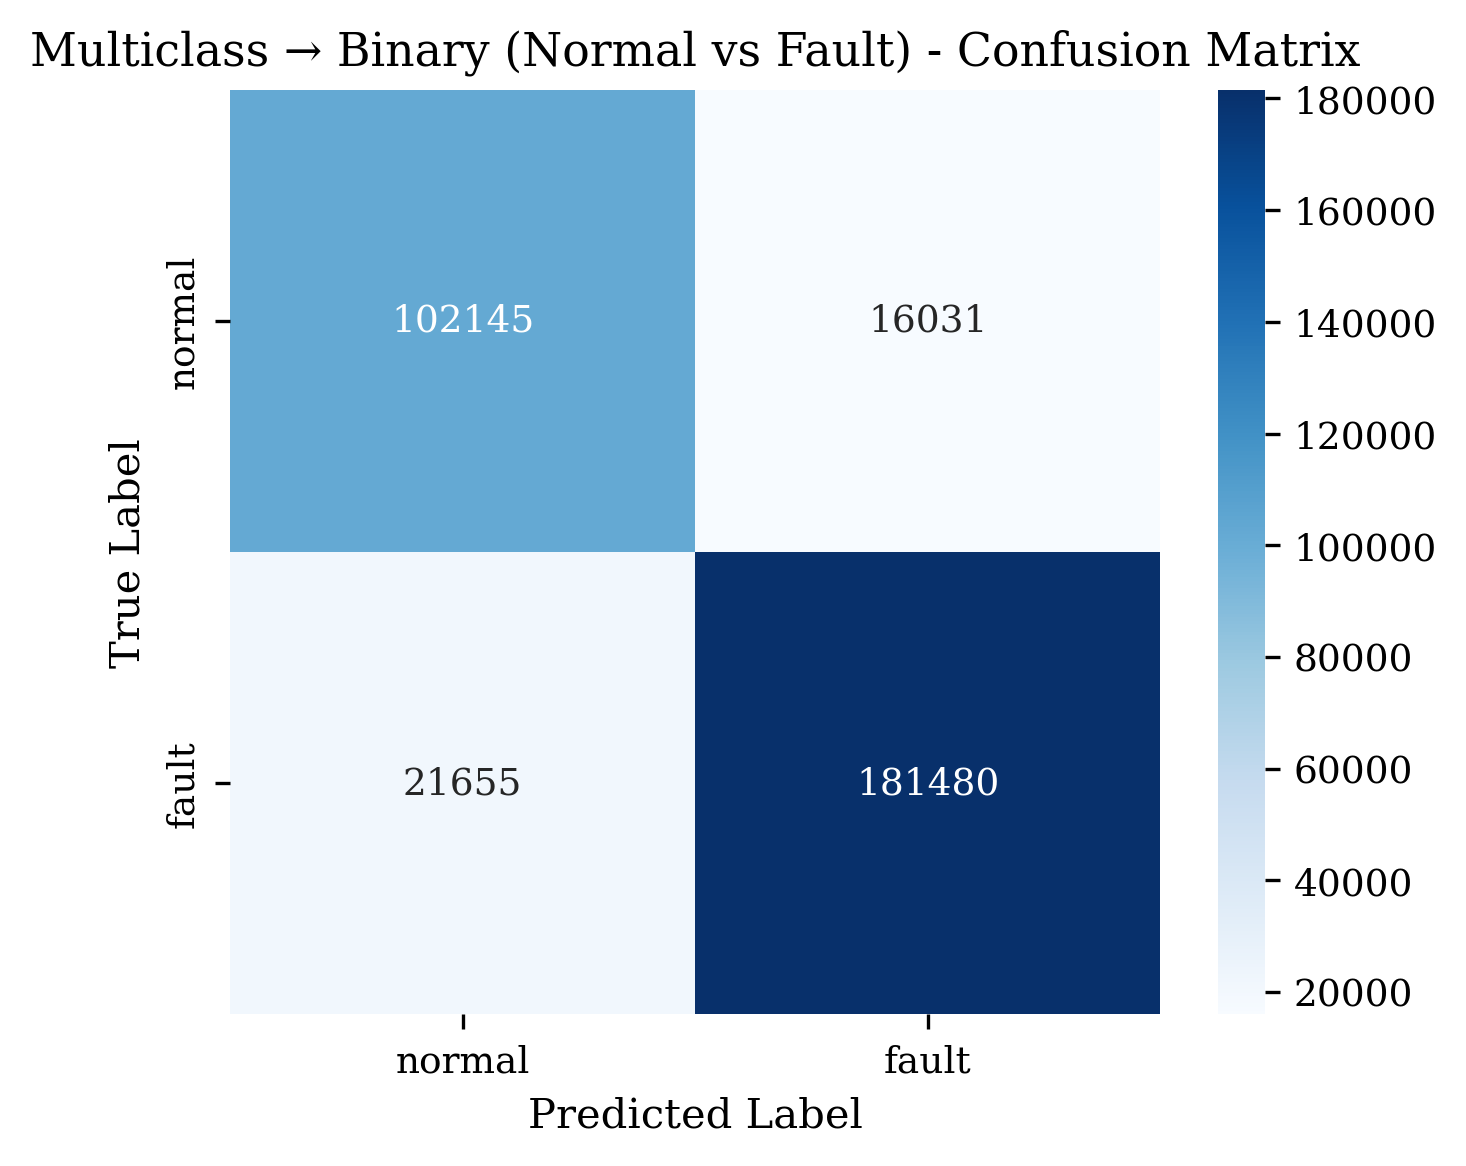

              precision    recall  f1-score   support

      normal       0.83      0.86      0.84    118176
       fault       0.92      0.89      0.91    203135

    accuracy                           0.88    321311
   macro avg       0.87      0.88      0.88    321311
weighted avg       0.88      0.88      0.88    321311



In [51]:
from sklearn.metrics import confusion_matrix, classification_report

# Map multiclass predictions/labels to binary: 0=normal, 1=fault
normal_label = "normal"
to_binary = lambda x: 0 if x == normal_label else 1

y_true_bin = predictions_df["multiclass_label"].map(to_binary).values
y_pred_bin = predictions_df["multiclass_prediction_state"].map(to_binary).values

cm_2class = confusion_matrix(y_true_bin, y_pred_bin)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(
    cm_2class, annot=True, fmt='d', cmap='Blues',
    xticklabels=['normal','fault'], yticklabels=['normal','fault'],
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Multiclass → Binary (Normal vs Fault) - Confusion Matrix')
plt.savefig("multiclass_to_binary_confusion_matrix.png", dpi=300)
plt.savefig("multiclass_to_binary_confusion_matrix.pdf", dpi=300)
plt.show()

print(classification_report(
    y_true_bin, y_pred_bin, target_names=['normal', 'fault']
))


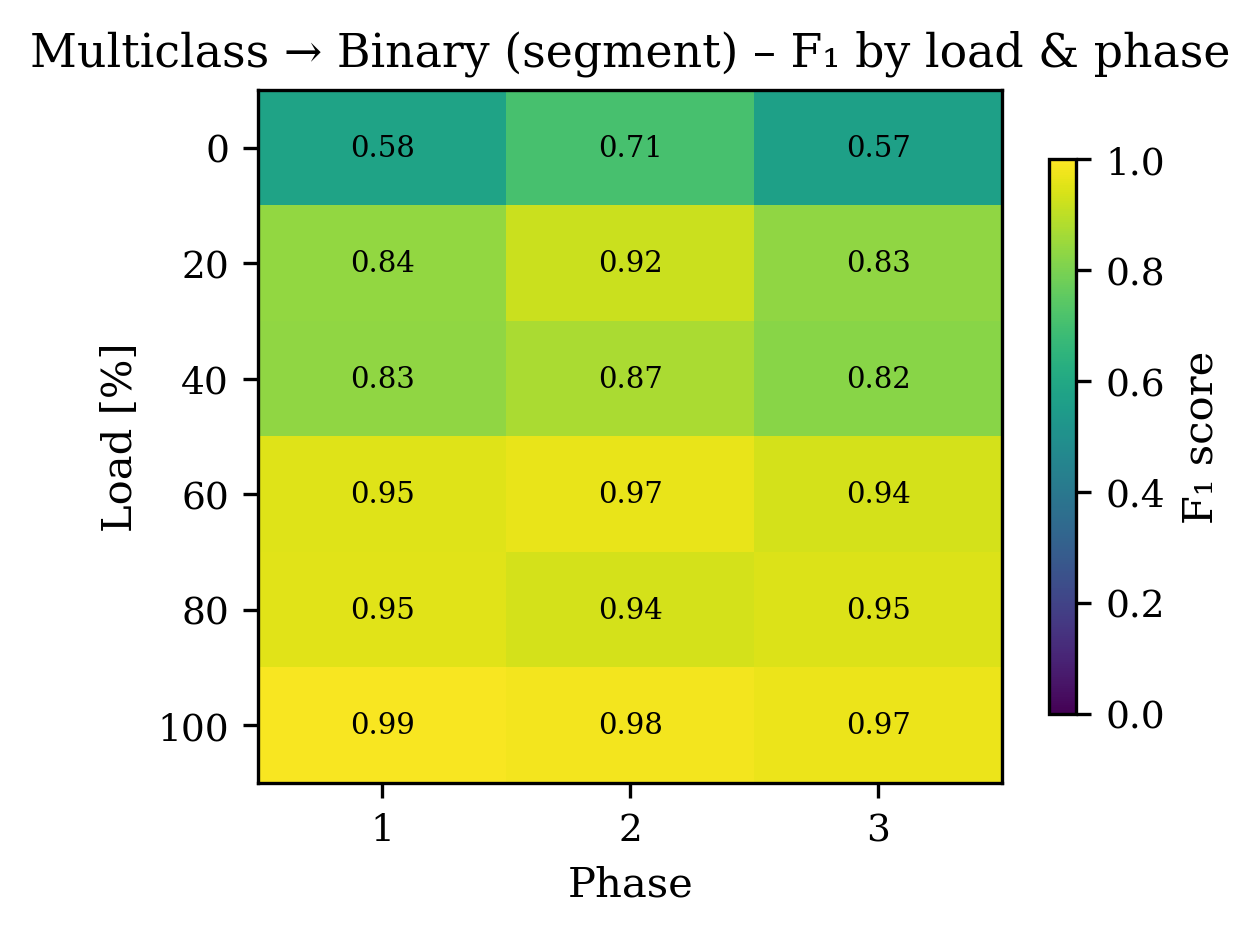

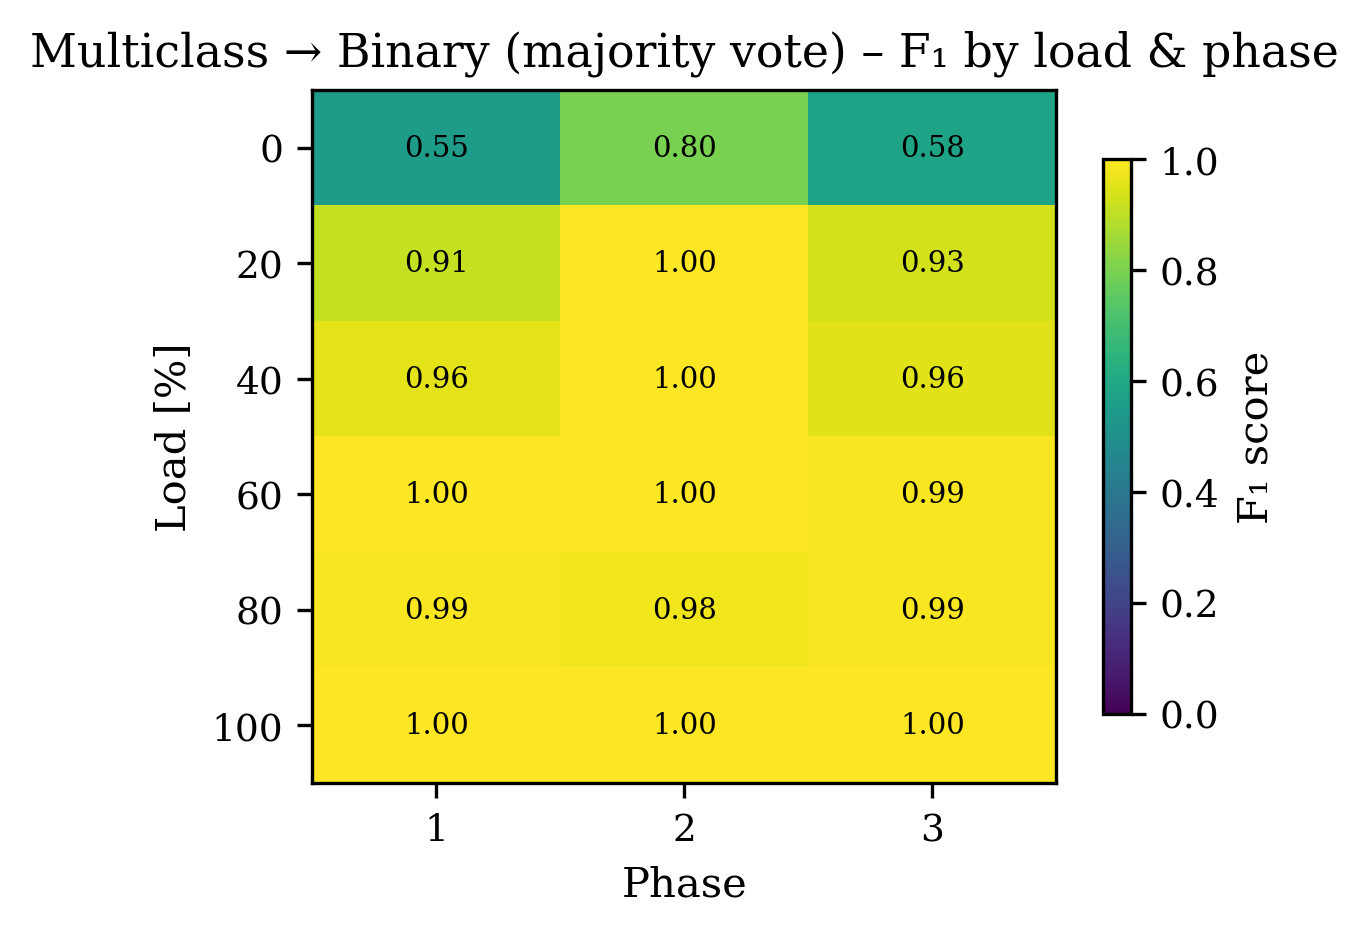

In [52]:
# Remap to binary at segment level
normal_label = "normal"
to_binary = lambda x: 0 if x == normal_label else 1

predictions_df["binary_label_from_multi"] = predictions_df["multiclass_label"].map(to_binary)
predictions_df["binary_pred_from_multi"] = predictions_df["multiclass_prediction_state"].map(to_binary)

# F1 by load & phase, segment level
bin_from_multi_metrics = slice_metrics(
    predictions_df,
    y_true="binary_label_from_multi",
    y_pred="binary_pred_from_multi",
    average="binary",
)
f1_bin_from_multi = bin_from_multi_metrics.pivot(index="load", columns="phase", values="f1")
n_bin_from_multi  = bin_from_multi_metrics.pivot(index="load", columns="phase", values="n")

plot_heatmap(
    f1_bin_from_multi,
    "Multiclass → Binary (segment) – F₁ by load & phase",
    save=True
)

# Remap to binary at measurement-majority level
label_counts["binary_true_from_multi"] = label_counts["true_label"].map(to_binary)
label_counts["binary_pred_majority_from_multi"] = label_counts["pred_majority_label"].map(to_binary)

# F1 by load & phase, majority vote
bin_mv_from_multi_metrics = slice_metrics(
    label_counts,
    y_true="binary_true_from_multi",
    y_pred="binary_pred_majority_from_multi",
    average="binary",
)
f1_bin_mv_from_multi = bin_mv_from_multi_metrics.pivot(index="load", columns="phase", values="f1")
n_bin_mv_from_multi  = bin_mv_from_multi_metrics.pivot(index="load", columns="phase", values="n")

plot_heatmap(
    f1_bin_mv_from_multi,
    "Multiclass → Binary (majority vote) – F₁ by load & phase",
    save=True
)


**Выводы**: 
1. качество модели зависит от нагрузки. Оставив загрузку в 100% мы получили хорошие результаты на всех загрузках, кроме 0 и 20 процентов.
2. Фазы не имеют особого влияния: модель обученная на одной фазе дает хорошие предсказания для других фаз

- Увеличить число эпох обучения
- Перепроверить число измерений, использованных для подсчета majority vote: возможно, их мало, возможно, мало соответсвующих им сегментов ->  в таком случае нужно вынести измерения из train и val и полностью закинуть в final test
